# BTwin — Early Adopter Tutorial

This notebook walks you through the core features of **BTwin** step by step: spatial hierarchy, equipment, properties, KPIs, sensors, serialization, and graph operations.

**Prerequisites:** `pip install btwin`

Run each section in order — later cells depend on objects created earlier.

In [ ]:
import btwin

## Schema

`Schema` exposes every ontology type and relationship name that BTwin recognises (Brick, BOT, IFC). Query it first to discover valid values before constructing objects.

In [ ]:
from btwin.schema import Schema

ModuleNotFoundError: No module named 'btwin'

In [ ]:
# List all recognised ontology types (Brick spatial, equipment, and point types; BOT; IFC)
spatialElementTypes = Schema.Types()
print(spatialElementTypes)

{'brick:Portfolio': {'IRI': 'https://brickschema.org/schema/Brick#Portfolio', 'description': "A collection that groups one or more Sites (e.g., an owner's portfolio)."}, 'brick:Region': {'IRI': 'https://brickschema.org/schema/Brick#Region', 'description': 'A location representing a geographic/administrative region used for grouping.'}, 'brick:Zone': {'IRI': 'https://brickschema.org/schema/Brick#Zone', 'description': 'A logical grouping of spaces defined by a subsystem (e.g., HVAC, lighting, fire).'}, 'brick:Energy_Zone': {'IRI': 'https://brickschema.org/schema/Brick#Energy_Zone', 'description': 'A Zone used for energy metering/management boundaries; subclass of brick:Zone.'}, 'brick:Fire_Zone': {'IRI': 'https://brickschema.org/schema/Brick#Fire_Zone', 'description': 'A subsection of the building that can be isolated by fire barriers/doors.'}, 'bot:Site': {'IRI': 'https://w3id.org/bot#Site', 'description': 'Top-level spatial container (e.g., campus/plot) that may contain Buildings.'}, '

In [ ]:
# List all valid relationship names used across the BTwin ontologies
spatialElementRelationships = Schema.RelationshipNames()
print(spatialElementRelationships)

{'brick:hasLocation': {'IRI': 'https://brickschema.org/schema/Brick#hasLocation', 'pairs': [{'subject': {'label': 'bot:Space', 'IRI': 'https://w3id.org/bot#Space'}, 'object': {'label': 'bot:Storey', 'IRI': 'https://w3id.org/bot#Storey'}}, {'subject': {'label': 'bot:Space', 'IRI': 'https://w3id.org/bot#Space'}, 'object': {'label': 'brick:Zone', 'IRI': 'https://brickschema.org/schema/Brick#Zone'}}, {'subject': {'label': 'bot:Space', 'IRI': 'https://w3id.org/bot#Space'}, 'object': {'label': 'brick:Energy_Zone', 'IRI': 'https://brickschema.org/schema/Brick#Energy_Zone'}}, {'subject': {'label': 'bot:Space', 'IRI': 'https://w3id.org/bot#Space'}, 'object': {'label': 'brick:Fire_Zone', 'IRI': 'https://brickschema.org/schema/Brick#Fire_Zone'}}, {'subject': {'label': 'bot:Storey', 'IRI': 'https://w3id.org/bot#Storey'}, 'object': {'label': 'bot:Building', 'IRI': 'https://w3id.org/bot#Building'}}, {'subject': {'label': 'bot:Building', 'IRI': 'https://w3id.org/bot#Building'}, 'object': {'label': 'b

## SpatialElement

A `SpatialElement` represents a physical location in a building hierarchy: site, building, storey, space, or zone. Use BOT and Brick type strings to classify each element, then use the relationship methods to wire them into a containment hierarchy.

In [ ]:
from btwin.spatial_element import SpatialElement

In [ ]:
# Create spatial elements: 3 spaces, a storey, and a building.
# Each element needs a unique UID and a valid ontology type string (see Schema.Types).
space1 = SpatialElement.Constructor(spatialElementUID='mySpace1', spatialElementType='bot:Space', name='mySpaceName1') 
print(space1)
space2 = SpatialElement.Constructor(spatialElementUID='mySpace2', spatialElementType='bot:Space', name='mySpaceName2')
print(space2)
space3 = SpatialElement.Constructor(spatialElementUID='mySpace3', spatialElementType='bot:Space', name='mySpaceName3')
print(space3)
storey = SpatialElement.Constructor(spatialElementUID='myStoreyUID', spatialElementType='bot:Storey', name='myStoreyName') 
print(storey)
building = SpatialElement.Constructor(spatialElementUID='myBuildingUID', spatialElementType='bot:Building', name='myBuildingName') 
print(building)

{'@id': 'mySpace1', '@type': 'bot:Space', 'relationships': {}, 'name': 'mySpaceName1'}
{'@id': 'mySpace2', '@type': 'bot:Space', 'relationships': {}, 'name': 'mySpaceName2'}
{'@id': 'mySpace3', '@type': 'bot:Space', 'relationships': {}, 'name': 'mySpaceName3'}
{'@id': 'myStoreyUID', '@type': 'bot:Storey', 'relationships': {}, 'name': 'myStoreyName'}
{'@id': 'myBuildingUID', '@type': 'bot:Building', 'relationships': {}, 'name': 'myBuildingName'}


In [ ]:
# Link a spatial element to another using a named relationship.
# You can pass either a linkedObject reference or explicit UID + type strings.
storey = SpatialElement.SetRelationship(spatialElementObject=storey, relationshipName='brick:hasLocation', linkedObjectUID='myBuildingUID', linkedObjectType='bot:Building')
print(storey)
space1 = SpatialElement.SetRelationship(spatialElementObject=space1, relationshipName='brick:hasLocation', linkedObjectUID='myStoreyUID', linkedObjectType='bot:Storey')
print(space1)
space2 = SpatialElement.SetRelationship(spatialElementObject=space2, relationshipName='brick:hasLocation', linkedObject=storey)
print(space2)

{'@id': 'myStoreyUID', '@type': 'bot:Storey', 'relationships': {'brick:hasLocation': [{'@id': 'myBuildingUID', '@type': 'bot:Building'}]}, 'name': 'myStoreyName'}
{'@id': 'mySpace1', '@type': 'bot:Space', 'relationships': {'brick:hasLocation': [{'@id': 'myStoreyUID', '@type': 'bot:Storey'}]}, 'name': 'mySpaceName1'}
{'@id': 'mySpace2', '@type': 'bot:Space', 'relationships': {'brick:hasLocation': [{'@id': 'myStoreyUID', '@type': 'bot:Storey'}]}, 'name': 'mySpaceName2'}


In [ ]:
# Shorthand for brick:hasLocation — place space3 inside the storey without specifying the relationship name.
space3 = SpatialElement.SetLocationRelationship(spatialElementObject=space3, linkedObject=storey)
print(space3)

{'@id': 'mySpace3', '@type': 'bot:Space', 'relationships': {'brick:hasLocation': [{'@id': 'myStoreyUID', '@type': 'bot:Storey'}]}, 'name': 'mySpaceName3'}


In [ ]:
# Read back the ontology type string of a spatial element
objectType = SpatialElement.Type(spatialElementObject=space1)
print(objectType)

bot:Space


In [ ]:
# Read back the unique identifier of a spatial element
objectUID = SpatialElement.UID(spatialElementObject=space1)
print(objectUID)

mySpace1


In [ ]:
# Inspect all relationships attached to a spatial element
objectRelationships = SpatialElement.Relationships(spatialElementObject=space1)
print(objectRelationships)

{'brick:hasLocation': [{'@id': 'myStoreyUID', '@type': 'bot:Storey'}]}


## Property & PropertySet

`Property` holds a single typed, named value following the IFC property model. `PropertySet` groups related properties under a shared UID and can be attached to any spatial element.

In [ ]:
from btwin.property_set import PropertySet, Property

In [ ]:
# Create typed properties: a label property for occupancy type and a numeric area measurement.
# propertyQuantity and propertyType follow IFC naming conventions.
prop1 = Property.Constructor(propertyName='occupancyType', propertyValue='office', propertyValues=None, propertyQuantity='IfcLabel', propertyType='IfcPropertySingleValue', propertyUnit='str')
print(prop1)
prop2 = Property.Constructor(propertyName='occupancyType', propertyValue='classroom', propertyValues=None, propertyQuantity='IfcLabel', propertyType='IfcPropertySingleValue',  propertyUnit='str')
print(prop2)
prop3 = Property.Constructor(propertyName='area', propertyValue=54, propertyValues=None, propertyQuantity='IfcQuantityArea', propertyType='IfcPropertySingleValue',  propertyUnit='sqm')
print(prop3)

{'@type': 'IfcPropertySingleValue', 'name': 'occupancyType', 'nominalValue': {'type': 'IfcLabel', 'value': 'office', 'unit': 'str'}}
{'@type': 'IfcPropertySingleValue', 'name': 'occupancyType', 'nominalValue': {'type': 'IfcLabel', 'value': 'classroom', 'unit': 'str'}}
{'@type': 'IfcPropertySingleValue', 'name': 'area', 'nominalValue': {'type': 'IfcQuantityArea', 'value': 54, 'unit': 'sqm'}}


In [ ]:
# Update the value, quantity type, and unit of an existing property in place
prop3 = Property.SetValue(property=prop3, propertyValue=34, propertyType='IfcPropertySingleValue', propertyQuantity='IfcQuantityArea', propertyUnit='sqm')
print(prop3)

{'@type': 'IfcPropertySingleValue', 'name': 'area', 'nominalValue': {'type': 'IfcQuantityArea', 'value': 34, 'unit': 'sqm'}}


In [ ]:
# Read the current value stored in a property
value = Property.Value(property=prop3)
print(value)

34


In [ ]:
# Read the IFC quantity type of a property (e.g. IfcQuantityArea, IfcLabel)
qtyType = Property.QuantityType(property=prop3)
print(qtyType)

IfcQuantityArea


In [ ]:
# Read the measurement unit of a property (e.g. 'sqm', 'str')
unit = Property.Unit(property=prop3)
print(unit)

sqm


In [ ]:
# Create property sets that will group related properties under a shared identifier
myPset1 = PropertySet.Constructor(psetUID='myPset1', psetName='Property Set 1')
print(myPset1)
myPset2 = PropertySet.Constructor(psetUID='myPset2', psetName='Property Set 1')
print(myPset2)

{'@id': 'myPset1', '@type': 'ifc:IfcPropertySet', 'name': 'Property Set 1', 'ifc:HasProperties': []}
{'@id': 'myPset2', '@type': 'ifc:IfcPropertySet', 'name': 'Property Set 1', 'ifc:HasProperties': []}


In [ ]:
# Read the unique identifier of a property set
print(PropertySet.UID(myPset1))

myPset1


In [ ]:
# Add properties to a set one at a time.
# overwrite=True replaces an existing property with the same name; False raises an error.
myPset = PropertySet.SetProperty(pset=myPset1, property=prop1, overwrite=False)
print(myPset)
myPset = PropertySet.SetProperty(pset=myPset1, property=prop2, overwrite=True)
print(myPset)
myPset = PropertySet.SetProperty(pset=myPset1, property=prop3, overwrite=False)
print(myPset)

{'@id': 'myPset1', '@type': 'ifc:IfcPropertySet', 'name': 'Property Set 1', 'ifc:HasProperties': [{'@type': 'IfcPropertySingleValue', 'name': 'occupancyType', 'nominalValue': {'type': 'IfcLabel', 'value': 'office', 'unit': 'str'}}]}
{'@id': 'myPset1', '@type': 'ifc:IfcPropertySet', 'name': 'Property Set 1', 'ifc:HasProperties': [{'@type': 'IfcPropertySingleValue', 'name': 'occupancyType', 'nominalValue': {'type': 'IfcLabel', 'value': 'classroom', 'unit': 'str'}}]}
{'@id': 'myPset1', '@type': 'ifc:IfcPropertySet', 'name': 'Property Set 1', 'ifc:HasProperties': [{'@type': 'IfcPropertySingleValue', 'name': 'occupancyType', 'nominalValue': {'type': 'IfcLabel', 'value': 'classroom', 'unit': 'str'}}, {'@type': 'IfcPropertySingleValue', 'name': 'area', 'nominalValue': {'type': 'IfcQuantityArea', 'value': 34, 'unit': 'sqm'}}]}


In [ ]:
# Add a list of properties to a set in one call
myPset2 = PropertySet.SetProperties(pset=myPset2, properties=[prop1, prop2, prop3], overwrite=False)
print(myPset2)

{'@id': 'myPset2', '@type': 'ifc:IfcPropertySet', 'name': 'Property Set 1', 'ifc:HasProperties': [{'@type': 'IfcPropertySingleValue', 'name': 'occupancyType', 'nominalValue': {'type': 'IfcLabel', 'value': 'office', 'unit': 'str'}}, {'@type': 'IfcPropertySingleValue', 'name': 'area', 'nominalValue': {'type': 'IfcQuantityArea', 'value': 34, 'unit': 'sqm'}}]}


In [ ]:
# List all properties currently stored in a property set
psetProperties = PropertySet.Properties(pset=myPset1)
print(psetProperties)

[{'@type': 'IfcPropertySingleValue', 'name': 'occupancyType', 'nominalValue': {'type': 'IfcLabel', 'value': 'classroom', 'unit': 'str'}}, {'@type': 'IfcPropertySingleValue', 'name': 'area', 'nominalValue': {'type': 'IfcQuantityArea', 'value': 34, 'unit': 'sqm'}}]


In [ ]:
# Retrieve a single property from a set by its name
psetProperty = PropertySet.Property(pset=myPset1, propertyName='occupancyType')
print(psetProperty)

{'@type': 'IfcPropertySingleValue', 'name': 'occupancyType', 'nominalValue': {'type': 'IfcLabel', 'value': 'classroom', 'unit': 'str'}}


In [ ]:
# Attach a property set to a spatial element so it appears as a node relationship in the graph
space1 = SpatialElement.SetPSetRelationship(spatialElementObject=space1, pset=myPset1)
print(space1)

{'@id': 'mySpace1', '@type': 'bot:Space', 'relationships': {'brick:hasLocation': [{'@id': 'myStoreyUID', '@type': 'bot:Storey'}], 'ifc:HasPropertySets': [{'@id': 'myPset1', '@type': 'ifc:IfcPropertySet'}]}, 'name': 'mySpaceName1'}


## KPI & KPISet

A `KPI` is a named, time-bounded metric with a numeric value and unit. A `KPISet` groups related KPIs, shares a time window across all of them, and links them to a spatial object for contextualisation.

In [ ]:
from btwin.kpi_set import KPISet, KPI

In [ ]:
# Create a KPI with a numeric value, unit, and initial evaluation period
kpi1 = KPI.Constructor(kpiUID='myKPI1', kpiName='Space Energy Use Intensity', kpiValue=44, kpiUnit='kWh/m2', hasBeginning='2025-01-01', hasEnd='2026-01-01') 
print(kpi1)

{'@id': 'myKPI1', '@type': 'eko:KPI', 'name': 'Space Energy Use Intensity', 'relationships': {'eko:hasAssociatedObject': [{'@id': None, '@type': None}], 'eko:hasEvaluationTimestep': [{'@type': 'time:interval', 'time:hasBeginning': '2025-01-01T00:00:00Z', 'time:hasEnd': '2026-01-01T00:00:00Z'}]}, 'nominalValue': {'@type': 'eko:KPI', 'value': 44, 'unit': 'kWh/m2'}}


In [ ]:
# Override the KPI's evaluation time window after construction
kpi1 = KPI.SetTimestep(kpi=kpi1, hasBeginning='2027-01-01', hasEnd='2028-01-01')
print(kpi1)

{'@id': 'myKPI1', '@type': 'eko:KPI', 'name': 'Space Energy Use Intensity', 'relationships': {'eko:hasAssociatedObject': [{'@id': None, '@type': None}], 'eko:hasEvaluationTimestep': [{'@type': 'time:interval', 'time:hasBeginning': '2027-01-01T00:00:00Z', 'time:hasEnd': '2028-01-01T00:00:00Z'}]}, 'nominalValue': {'@type': 'eko:KPI', 'value': 44, 'unit': 'kWh/m2'}}


In [ ]:
# Read the numeric value stored in the KPI
print(KPI.Value(kpi1))

44


In [ ]:
# Read the unique identifier of a KPI
print(KPI.UID(kpi1))

myKPI1


In [ ]:
# Read the human-readable name of a KPI
print(KPI.Name(kpi1))

Space Energy Use Intensity


In [ ]:
# Read the start and end timestamps of a KPI's evaluation window
print(KPI.Timestep(kpi1))

{'time:hasBeginning': '2027-01-01T00:00:00Z', 'time:hasEnd': '2028-01-01T00:00:00Z'}


In [ ]:
# Create KPI sets that group related KPIs under a shared time window
kpiset1 = KPISet.Constructor(kpisetUID="myKPISet1", name='KPISet 1', hasBeginning='2025-01-13', hasEnd='2025-02-14 00:00')
print(kpiset1)
kpiset2 = KPISet.Constructor(kpisetUID="myKPISet2", name='KPISet 2', hasBeginning='2025-01-13', hasEnd='2025-02-14 23:59')
print(kpiset2)

{'@id': 'myKPISet1', 'name': 'KPISet 1', '@type': 'btwin:KPISet', 'relationships': {'eko:hasEvaluationTimestep': [{'@type': 'time:interval', 'time:hasBeginning': '2025-01-13T00:00:00', 'time:hasEnd': '2025-02-14T00:00:00'}]}, 'btwin:hasKPIs': {}}
{'@id': 'myKPISet2', 'name': 'KPISet 2', '@type': 'btwin:KPISet', 'relationships': {'eko:hasEvaluationTimestep': [{'@type': 'time:interval', 'time:hasBeginning': '2025-01-13T00:00:00', 'time:hasEnd': '2025-02-14T23:59:00'}]}, 'btwin:hasKPIs': {}}


In [ ]:
# Override the shared time window of a KPI set after construction
kpiset1 = KPISet.SetTimestep(kpiSet=kpiset1, hasBeginning='2026-01-13 00:00', hasEnd='2026-02-14 00:00')
print(kpiset1)

{'@id': 'myKPISet1', 'name': 'KPISet 1', '@type': 'btwin:KPISet', 'relationships': {'eko:hasEvaluationTimestep': [{'@type': 'time:interval', 'time:hasBeginning': '2026-01-13T00:00:00Z', 'time:hasEnd': '2026-02-14T00:00:00Z'}]}, 'btwin:hasKPIs': {}}


In [ ]:
# Link a KPI set to a spatial object via a named relationship
kpiset1 = KPISet.SetRelationship(kpiSet=kpiset1, relationshipName='eko:hasAssociatedObject', linkedObject=space1)
print(kpiset1)

{'@id': 'myKPISet1', 'name': 'KPISet 1', '@type': 'btwin:KPISet', 'relationships': {'eko:hasEvaluationTimestep': [{'@type': 'time:interval', 'time:hasBeginning': '2026-01-13T00:00:00Z', 'time:hasEnd': '2026-02-14T00:00:00Z'}], 'eko:hasAssociatedObject': [{'@id': 'mySpace1', '@type': 'bot:Space'}]}, 'btwin:hasKPIs': {}}


In [ ]:
# Shorthand for eko:hasAssociatedObject — associate a KPI set with a spatial object directly
kpiset2 = KPISet.SetAssociatedObject(kpiSet=kpiset2, linkedObject=space2)
print(kpiset2)

{'@id': 'myKPISet2', 'name': 'KPISet 2', '@type': 'btwin:KPISet', 'relationships': {'eko:hasEvaluationTimestep': [{'@type': 'time:interval', 'time:hasBeginning': '2025-01-13T00:00:00', 'time:hasEnd': '2025-02-14T23:59:00'}], 'eko:hasAssociatedObject': [{'@id': 'mySpace2', '@type': 'bot:Space'}]}, 'btwin:hasKPIs': {}}


In [ ]:
# Read the unique identifier of a KPI set
print(KPISet.UID(kpiset1))

myKPISet1


In [ ]:
# Add a KPI to the set; overwrite=False raises an error if the UID already exists in the set
kpiset1 = KPISet.SetKPI(kpiSet=kpiset1, kpi=kpi1, overwrite=False)
print(kpiset1)

{'@id': 'myKPISet1', 'name': 'KPISet 1', '@type': 'btwin:KPISet', 'relationships': {'eko:hasEvaluationTimestep': [{'@type': 'time:interval', 'time:hasBeginning': '2026-01-13T00:00:00Z', 'time:hasEnd': '2026-02-14T00:00:00Z'}], 'eko:hasAssociatedObject': [{'@id': 'mySpace1', '@type': 'bot:Space'}]}, 'btwin:hasKPIs': {'myKPI1': {'@id': 'myKPI1', '@type': 'eko:KPI', 'name': 'Space Energy Use Intensity', 'relationships': {'eko:hasAssociatedObject': [{'@id': None, '@type': None}], 'eko:hasEvaluationTimestep': [{'@type': 'time:interval', 'time:hasBeginning': '2027-01-01T00:00:00Z', 'time:hasEnd': '2028-01-01T00:00:00Z'}]}, 'nominalValue': {'@type': 'eko:KPI', 'value': 44, 'unit': 'kWh/m2'}}}}


In [ ]:
# Propagate the KPI set's time window down to all its contained KPIs at once
kpiset1 = KPISet.SetKPIsTimestep(kpiSet=kpiset1)
print(kpiset1)

{'@id': 'myKPISet1', 'name': 'KPISet 1', '@type': 'btwin:KPISet', 'relationships': {'eko:hasEvaluationTimestep': [{'@type': 'time:interval', 'time:hasBeginning': '2026-01-13T00:00:00Z', 'time:hasEnd': '2026-02-14T00:00:00Z'}], 'eko:hasAssociatedObject': [{'@id': 'mySpace1', '@type': 'bot:Space'}]}, 'btwin:hasKPIs': {'myKPI1': {'@id': 'myKPI1', '@type': 'eko:KPI', 'name': 'Space Energy Use Intensity', 'relationships': {'eko:hasAssociatedObject': [{'@id': None, '@type': None}], 'eko:hasEvaluationTimestep': [{'@type': 'time:interval', 'time:hasBeginning': '2026-01-13T00:00:00Z', 'time:hasEnd': '2026-02-14T00:00:00Z'}]}, 'nominalValue': {'@type': 'eko:KPI', 'value': 44, 'unit': 'kWh/m2'}}}}


## Scenario

A `Scenario` is a named analysis context with an optional description. Attach `KPISet`s and `Document`s to a scenario to compare design alternatives or evaluation periods.

In [ ]:
from btwin.scenario import Scenario

In [ ]:
# Create a named scenario with an optional free-text description
scenario1 = Scenario.Constructor(scenarioUID='myScenario', name = 'My scenario', description="This is an example scenario")
print(scenario1)

{'@id': 'myScenario', '@type': 'kpi:Scenario', 'relationships': {}, 'name': 'My scenario', 'description': 'This is an example scenario'}


In [ ]:
# Attach both KPI sets to the same scenario so they share an analysis context
kpiset1 = KPISet.SetScenario(kpiSet=kpiset1, scenarioObject=scenario1)
print(kpiset1)
kpiset2 = KPISet.SetScenario(kpiSet=kpiset2, scenarioObject=scenario1)
print(kpiset2)

{'@id': 'myKPISet1', 'name': 'KPISet 1', '@type': 'btwin:KPISet', 'relationships': {'eko:hasEvaluationTimestep': [{'@type': 'time:interval', 'time:hasBeginning': '2026-01-13T00:00:00Z', 'time:hasEnd': '2026-02-14T00:00:00Z'}], 'eko:hasAssociatedObject': [{'@id': 'mySpace1', '@type': 'bot:Space'}], 'kpi:relatedScenario': [{'@id': 'myScenario', '@type': 'kpi:Scenario'}]}, 'btwin:hasKPIs': {'myKPI1': {'@id': 'myKPI1', '@type': 'eko:KPI', 'name': 'Space Energy Use Intensity', 'relationships': {'eko:hasAssociatedObject': [{'@id': None, '@type': None}], 'eko:hasEvaluationTimestep': [{'@type': 'time:interval', 'time:hasBeginning': '2026-01-13T00:00:00Z', 'time:hasEnd': '2026-02-14T00:00:00Z'}]}, 'nominalValue': {'@type': 'eko:KPI', 'value': 44, 'unit': 'kWh/m2'}}}}
{'@id': 'myKPISet2', 'name': 'KPISet 2', '@type': 'btwin:KPISet', 'relationships': {'eko:hasEvaluationTimestep': [{'@type': 'time:interval', 'time:hasBeginning': '2025-01-13T00:00:00', 'time:hasEnd': '2025-02-14T23:59:00'}], 'eko:h

In [ ]:
# Read scenario metadata: unique ID, human-readable name, and description
print(Scenario.UID(scenario1))

# Scenario.Name
print(Scenario.Name(scenario1))

# Scenario.Description
print(Scenario.Description(scenario1))

myScenario
My scenario
This is an example scenario


## Document

A `Document` wraps a reference to an external file (e.g. an IFC model). Link it to spatial objects and scenarios to track which file belongs to which analysis context.

In [ ]:
from btwin.document import Document

In [ ]:
# Wrap an external file reference as a document object
document = Document.Constructor(documentObjectUID='myDocument.ifc', name='Modello IFC edificio')
print(document)

{'@id': 'myDocument.ifc', '@type': 'btwin:Document', 'relationships': {}, 'name': 'Modello IFC edificio'}


In [ ]:
# Link the document to the building it describes
document = Document.SetRelationship(documentObject=document, relationshipName='btwin:isDocumentOf', linkedObject=building)
print(document)

{'@id': 'myDocument.ifc', '@type': 'btwin:Document', 'relationships': {'btwin:isDocumentOf': [{'@id': 'myBuildingUID', '@type': 'bot:Building'}]}, 'name': 'Modello IFC edificio'}


In [ ]:
# Associate the document with an analysis scenario
document = Document.SetScenario(documentObject=document, scenarioObject=scenario1)
print(document)

{'@id': 'myDocument.ifc', '@type': 'btwin:Document', 'relationships': {'btwin:isDocumentOf': [{'@id': 'myBuildingUID', '@type': 'bot:Building'}], 'kpi:relatedScenario': [{'@id': 'myScenario', '@type': 'kpi:Scenario'}]}, 'name': 'Modello IFC edificio'}


In [ ]:
# Read document metadata: unique ID, name, and all declared relationships
print(Document.UID(documentObject=document))

# Document.Name
print(Document.Name(documentObject=document))

# Document.Relationships
print(Document.Relationships(documentObject=document))

myDocument.ifc
Modello IFC edificio
{'btwin:isDocumentOf': [{'@id': 'myBuildingUID', '@type': 'bot:Building'}], 'kpi:relatedScenario': [{'@id': 'myScenario', '@type': 'kpi:Scenario'}]}


## Equipment & Inventory

`Equipment` represents physical devices (HVAC units, sensors, systems) classified with Brick types. Use the relationship methods to place them in spaces and connect them to each other. `Inventory` provides bulk import from an Excel template.

In [ ]:
from btwin.equipment import Equipment, Inventory

In [ ]:
# Create equipment objects using Brick type strings: a fan coil unit, a heat pump, and an HVAC system
fancoil = Equipment.Constructor(equipmentObjectUID='myFancoil1',equipmentObjectType="brick:Fan_Coil_Unit", name="Fancoil")
print(fancoil)
heatpump = Equipment.Constructor(equipmentObjectUID='heatpump1',equipmentObjectType="brick:Packaged_Heat_Pump", name="Heat pump")
print(heatpump)
heatingSystem = Equipment.Constructor(equipmentObjectUID='myHeatingSystem',equipmentObjectType="brick:HVAC_System", name="Heating system")
print(heatingSystem)

{'@id': 'myFancoil1', '@type': 'brick:Fan_Coil_Unit', 'relationships': {}, 'name': 'Fancoil'}
{'@id': 'heatpump1', '@type': 'brick:Packaged_Heat_Pump', 'relationships': {}, 'name': 'Heat pump'}
{'@id': 'myHeatingSystem', '@type': 'brick:HVAC_System', 'relationships': {}, 'name': 'Heating system'}


In [ ]:
# Wire up location, part-of, and feeds relationships between equipment objects.
# SetLocationRelationship and SetFeedingRelationship / SetPartOfRelationship are shorthands
# for brick:hasLocation, brick:feeds, and brick:isPartOf respectively.
fancoil = Equipment.SetRelationship(equipmentObject=fancoil,linkedObject=space1,relationshipName='brick:hasLocation')
fancoil = Equipment.SetRelationship(equipmentObject=fancoil,linkedObject=heatingSystem,relationshipName='brick:isPartOf')
print(fancoil)
# Equipment.SetLocationRelationship
heatpump = Equipment.SetLocationRelationship(equipmentObject=heatpump,linkedObject=space2)
# Equipment.SetFeedsRelationship
heatpump = Equipment.SetFeedingRelationship(equipmentObject=heatpump,linkedObject=fancoil)
# Equipment.SetIsPartOfRelationship
heatpump = Equipment.SetPartOfRelationship(equipmentObject=heatpump,linkedObject=heatingSystem)
print(heatpump)

{'@id': 'myFancoil1', '@type': 'brick:Fan_Coil_Unit', 'relationships': {'brick:hasLocation': [{'@id': 'mySpace1', '@type': 'bot:Space'}], 'brick:isPartOf': [{'@id': 'myHeatingSystem', '@type': 'brick:HVAC_System'}]}, 'name': 'Fancoil'}
{'@id': 'heatpump1', '@type': 'brick:Packaged_Heat_Pump', 'relationships': {'brick:hasLocation': [{'@id': 'mySpace2', '@type': 'bot:Space'}], 'brick:feeds': [{'@id': 'myFancoil1', '@type': 'brick:Fan_Coil_Unit'}], 'brick:isPartOf': [{'@id': 'myHeatingSystem', '@type': 'brick:HVAC_System'}]}, 'name': 'Heat pump'}


In [ ]:
# Read equipment metadata: Brick type, unique ID, name, and all declared relationships
print(Equipment.Type(heatpump))
# Equipment.UID
print(Equipment.UID(heatpump))
# Equipment.Name
print(Equipment.Name(heatpump))
# Equipment.Relationships
print(Equipment.Relationships(heatpump))

brick:Packaged_Heat_Pump
heatpump1
Heat pump
{'brick:hasLocation': [{'@id': 'mySpace2', '@type': 'bot:Space'}], 'brick:feeds': [{'@id': 'myFancoil1', '@type': 'brick:Fan_Coil_Unit'}], 'brick:isPartOf': [{'@id': 'myHeatingSystem', '@type': 'brick:HVAC_System'}]}


In [ ]:
# List all supported Brick equipment types you can use with Equipment.Constructor
print(Equipment.Types())

['brick:Equipment', 'brick:HVAC_Equipment', 'brick:Electrical_Equipment', 'brick:Lighting_Equipment', 'brick:Mechanical_Equipment', 'brick:Plumbing_Equipment', 'brick:Fire_Safety_Equipment', 'brick:Air_Handling_Unit', 'brick:Fan_Coil_Unit', 'brick:Variable_Air_Volume_Box', 'brick:Constant_Air_Volume_Box', 'brick:Chiller', 'brick:Boiler', 'brick:Heat_Exchanger', 'brick:Cooling_Tower', 'brick:Heat_Pump', 'brick:Air_Conditioning_Unit', 'brick:Dehumidifier', 'brick:Humidifier', 'brick:Condensing_Unit', 'brick:Reheat_Coil', 'brick:Cooling_Coil', 'brick:Heating_Coil', 'brick:Compressor', 'brick:Economizer', 'brick:Energy_Recovery_Ventilator', 'brick:Air_Filter', 'brick:Air_Damper', 'brick:Fan', 'brick:Supply_Fan', 'brick:Return_Fan', 'brick:Exhaust_Fan', 'brick:Relief_Fan', 'brick:Pump', 'brick:Chilled_Water_Pump', 'brick:Condenser_Water_Pump', 'brick:Hot_Water_Pump', 'brick:Booster_Pump', 'brick:Circulation_Pump', 'brick:Variable_Speed_Pump', 'brick:Valve', 'brick:Control_Valve', 'brick:Mix

In [ ]:
# Generate an empty Excel template for bulk equipment import.
# Fill in the spreadsheet and pass it to Inventory.ToJSONLD to create equipment objects.
print(Inventory.Template(savePath='inventory.xlsx'))

     id                 name                      type brick:isPartOf System  \
0  ahu1  AHU (below ceiling)   brick:Air_Handling_Unit         heatingSystem   
1  ahu2  AHU (below ceiling)   brick:Air_Handling_Unit         heatingSystem   
2   fc1             Fan coil       brick:Fan_Coil_Unit         heatingSystem   
3   hp1            Heat pump  brick:Packaged_Heat_Pump         heatingSystem   
4  hwb1     Hot water boiler     brick:Electric_Boiler             dhwSystem   

  brick:hasLocation  
0          mySpace1  
1          mySpace2  
2          mySpace1  
3          mySpace1  
4          mySpace2  


In [ ]:
# Import the filled inventory template and convert all rows to BTwin equipment objects
inventory = Inventory.ToJSONLD(xlsxPath='inventory.xlsx', createSystems=True, buildingUID=SpatialElement.UID(building))
print(inventory)

[{'@id': 'ahu1', '@type': 'brick:Air_Handling_Unit', 'relationships': {'brick:isPartOf': [{'@id': 'heatingSystem', '@type': 'brick:System'}], 'brick:hasLocation': [{'@id': 'mySpace1', '@type': 'bot:Space'}]}, 'name': 'AHU (below ceiling)'}, {'@id': 'ahu2', '@type': 'brick:Air_Handling_Unit', 'relationships': {'brick:isPartOf': [{'@id': 'heatingSystem', '@type': 'brick:System'}], 'brick:hasLocation': [{'@id': 'mySpace2', '@type': 'bot:Space'}]}, 'name': 'AHU (below ceiling)'}, {'@id': 'fc1', '@type': 'brick:Fan_Coil_Unit', 'relationships': {'brick:isPartOf': [{'@id': 'heatingSystem', '@type': 'brick:System'}], 'brick:hasLocation': [{'@id': 'mySpace1', '@type': 'bot:Space'}]}, 'name': 'Fan coil'}, {'@id': 'hp1', '@type': 'brick:Packaged_Heat_Pump', 'relationships': {'brick:isPartOf': [{'@id': 'heatingSystem', '@type': 'brick:System'}], 'brick:hasLocation': [{'@id': 'mySpace1', '@type': 'bot:Space'}]}, 'name': 'Heat pump'}, {'@id': 'hwb1', '@type': 'brick:Electric_Boiler', 'relationships'

## Point & Observation

A `Point` is a sensor or actuator reference classified with a Brick type. `Observation` methods write and query time-series values to and from a local SQLite database.

In [ ]:
from btwin.point import Point, Observation

In [ ]:
# List all supported Brick point (sensor and actuator) types
print(Point.Types())

['brick:Point', 'brick:Sensor', 'brick:Command', 'brick:Setpoint', 'brick:Status', 'brick:Alarm', 'brick:Temperature_Sensor', 'brick:Temperature_Setpoint', 'brick:Temperature_Command', 'brick:Temperature_Status', 'brick:CO2_Sensor', 'brick:CO_Sensor', 'brick:VOC_Sensor', 'brick:PM2.5_Sensor', 'brick:PM10_Sensor', 'brick:Humidity_Sensor', 'brick:Power_Sensor', 'brick:Energy_Sensor', 'brick:Voltage_Sensor', 'brick:Current_Sensor', 'brick:Frequency_Sensor', 'brick:BTU_Meter', 'brick:Heat_Meter', 'brick:Flow_Sensor', 'brick:Pressure_Sensor', 'brick:Air_Flow_Sensor', 'brick:Water_Flow_Sensor', 'brick:Static_Pressure_Sensor', 'brick:Differential_Pressure_Sensor', 'brick:Damper_Position_Sensor', 'brick:Valve_Position_Sensor', 'brick:Fan_Status', 'brick:Pump_Status', 'brick:Damper_Command', 'brick:Valve_Command', 'brick:Fan_Command', 'brick:Pump_Command', 'brick:Luminance_Sensor', 'brick:Illuminance_Sensor', 'brick:Light_Status', 'brick:Light_Command', 'brick:Occupancy_Sensor', 'brick:Motion_S

In [ ]:
# Create a sensor point with a Brick type and a human-readable name
point = Point.Constructor(pointUID="A temperature point", pointType="brick:Temperature_Sensor", name="Temperature Sensor")
print(point)

{'@id': 'A temperature point', '@type': 'brick:Temperature_Sensor', 'relationships': {}, 'name': 'Temperature Sensor'}


In [ ]:
# Read point metadata: unique ID, name, and declared relationships
print(Point.UID(point))
# Point.Name
print(Point.Name(point))
# Point.Relationships
print(Point.Relationships(point))

A temperature point
Temperature Sensor
{}


In [ ]:
# Generate an empty DataFrame template with the columns expected for storing observations
df = Observation.Template('observations')
print(df)

✅ Template saved successfully to: observations.xlsx
   sosa:madeBySensor sosa:ObservedProperty unit  value         timestamp
0  temperaturePoint1           Temperature   °C   22.5  2025-03-01 10:00
1  temperaturePoint1           Temperature   °C   22.7  2025-03-01 10:10
2  temperaturePoint1           Temperature   °C   22.8  2025-03-01 10:20
3  temperaturePoint1           Temperature   °C   22.3  2025-03-01 10:30


In [ ]:
# Write observations from a DataFrame to a SQLite table.
# The try/except handles the case where the DataFrame is empty (template has no data rows).
try:
    Observation.SQLiteByDF(df=df, sqlitePath="observations.db", tableName='observations')
except Exception as e:
    print(e)

Table 'observations' already exists (ifExists='fail').


In [ ]:
# Write observations from an Excel file directly to a SQLite table.
# The examples/data/observations.xlsx file contains sample data you can use.
try:
    Observation.SQLiteByXLSX(xlsxPath="observations.xlsx", sqlitePath="observations2.db", tableName='observations')
except Exception as e:
    print(e)

Table 'observations' already exists (ifExists='fail').


In [ ]:
# Query stored observations with optional sensor filter, property, time range, aggregation, and time binning.
# aggregate='max' and groupByTime='hour' return the hourly maximum over the specified window.
dfQuery = Observation.SQLiteQuery(
    sqlitePath="observations.db",
    tableName="observations",
    sensor=["temperaturePoint1", "temperaturePoint2"],
    observedProperty="Temperature",
    aggregate="max",
    groupByTime="hour",
    startTime="2025-03-01 10:00",
    endTime="2025-03-01 10:15"
)
print(dfQuery,'\n')

   sosa:madeBySensor sosa:ObservedProperty unit               period  \
0  temperaturePoint1           Temperature   °C  2025-03-01T10:00:00   

   Value_max  
0       22.7   



## Serialization

`Serialization` converts the in-memory object graph to JSON-LD with full ontology context. The output file can be reloaded into a NetworkX graph or converted to RDF/Turtle for SPARQL queries.

In [ ]:
from btwin.serialization import Serialization

In [ ]:
# List all ontology namespace IRIs included in the JSON-LD @context block
iris = Serialization.IRIs()
print(iris)

{'prefixes': {'brick': 'https://brickschema.org/schema/Brick#', 'bot': 'https://w3id.org/bot#', 'ifc': 'https://standards.buildingsmart.org/IFC/DEV/IFC4/ADD2_TC1/OWL#', 'eko': 'http://energy.linkeddata.es/em-kpi/ontology#', 'kpi': 'http://bimerr.iot.linkeddata.es/def/key-performance-indicator#', 'btwin': 'btwin#', 'top': 'top#', 'time': 'https://www.w3.org/TR/2022/CRD-owl-time-20221115#'}, 'classes': {'brick:Portfolio': 'https://brickschema.org/schema/Brick#Portfolio', 'brick:Region': 'https://brickschema.org/schema/Brick#Region', 'brick:Site': 'https://brickschema.org/schema/Brick#Site', 'brick:Building': 'https://brickschema.org/schema/Brick#Building', 'brick:Storey': 'https://brickschema.org/schema/Brick#Storey', 'brick:Space': 'https://brickschema.org/schema/Brick#Space', 'brick:Zone': 'https://brickschema.org/schema/Brick#Zone', 'brick:Energy_Zone': 'https://brickschema.org/schema/Brick#Energy_Zone', 'brick:Fire_Zone': 'https://brickschema.org/schema/Brick#Fire_Zone', 'brick:Equip

In [ ]:
# Export all in-memory objects to a single JSON-LD file.
# Pass every object you want serialised — objects not listed here will not appear in the graph.
jsonld = Serialization.JSONLODByObjects(objects=[
    building, space1, space2, space3, storey, myPset1, kpiset1, kpiset2, scenario1, document, inventory
    ], 
    savePath='examples/testGraph_JSONLD.json')
print(jsonld)

{'@context': {'brick': 'https://brickschema.org/schema/Brick#', 'bot': 'https://w3id.org/bot#', 'ifc': 'https://standards.buildingsmart.org/IFC/DEV/IFC4/ADD2_TC1/OWL#', 'eko': 'http://energy.linkeddata.es/em-kpi/ontology#', 'kpi': 'http://bimerr.iot.linkeddata.es/def/key-performance-indicator#', 'btwin': 'btwin#', 'time': 'https://www.w3.org/TR/2022/CRD-owl-time-20221115#'}, '@graph': [{'@id': 'myBuildingUID', '@type': 'bot:Building', 'relationships': {}, 'name': 'myBuildingName'}, {'@id': 'mySpace1', '@type': 'bot:Space', 'relationships': {'brick:hasLocation': [{'@id': 'myStoreyUID', '@type': 'bot:Storey'}], 'ifc:HasPropertySets': [{'@id': 'myPset1', '@type': 'ifc:IfcPropertySet'}]}, 'name': 'mySpaceName1'}, {'@id': 'mySpace2', '@type': 'bot:Space', 'relationships': {'brick:hasLocation': [{'@id': 'myStoreyUID', '@type': 'bot:Storey'}]}, 'name': 'mySpaceName2'}, {'@id': 'mySpace3', '@type': 'bot:Space', 'relationships': {'brick:hasLocation': [{'@id': 'myStoreyUID', '@type': 'bot:Storey

## Graph

`NetworkX` builds a directed graph from BTwin objects, validates it, and provides query, subgraph, compaction, and export utilities. `RDF` converts the same data to an RDF graph serialised as Turtle (requires `pip install btwin[neo4j]` for Neo4j export).

In [ ]:
from btwin.graph import NetworkX, RDF

In [ ]:
# Create an empty named directed graph that will hold all BTwin objects as nodes
nxGraph = NetworkX.Constructor(name='myGraph')
print(nxGraph)

MultiDiGraph named 'myGraph' with 0 nodes and 0 edges


In [ ]:
# Add each BTwin object as a node (without edges).
# Use AddEdgesByObject in the next cell to connect them.
nxGraph = NetworkX.AddNodeByObject(nxGraph=nxGraph, object=space1)
nxGraph = NetworkX.AddNodeByObject(nxGraph=nxGraph, object=space2)
nxGraph = NetworkX.AddNodeByObject(nxGraph=nxGraph, object=space3)
nxGraph = NetworkX.AddNodeByObject(nxGraph=nxGraph, object=storey)
nxGraph = NetworkX.AddNodeByObject(nxGraph=nxGraph, object=building)
nxGraph = NetworkX.AddNodeByObject(nxGraph=nxGraph, object=myPset1)
nxGraph = NetworkX.AddNodeByObject(nxGraph=nxGraph, object=kpiset1)
nxGraph = NetworkX.AddNodeByObject(nxGraph=nxGraph, object=kpiset2)
nxGraph = NetworkX.AddNodeByObject(nxGraph=nxGraph, object=scenario1) 
nxGraph = NetworkX.AddNodeByObject(nxGraph=nxGraph, object=document) 
print(nxGraph)

MultiDiGraph named 'myGraph' with 10 nodes and 0 edges


In [ ]:
# Add directed edges derived from each object's declared relationships.
# Only objects that have relationships set (via SetRelationship etc.) generate edges.
nxGraph = NetworkX.AddEdgesByObject(nxGraph, space1)
nxGraph = NetworkX.AddEdgesByObject(nxGraph, space2)
nxGraph = NetworkX.AddEdgesByObject(nxGraph, space3)
nxGraph = NetworkX.AddEdgesByObject(nxGraph, storey)
nxGraph = NetworkX.AddEdgesByObject(nxGraph, kpiset1)
nxGraph = NetworkX.AddEdgesByObject(nxGraph, kpiset2)
nxGraph = NetworkX.AddEdgesByObject(nxGraph, scenario1)
nxGraph = NetworkX.AddEdgesByObject(nxGraph, document)
print(nxGraph)

MultiDiGraph named 'myGraph' with 10 nodes and 11 edges


In [ ]:
# Validate the graph: checks for missing node references, duplicate UIDs, and broken edges
nxGraph = NetworkX.Validate(nxGraph=nxGraph)
print(nxGraph)

✓ NetworkX validation passed (all node/edge types are valid).
MultiDiGraph named 'myGraph' with 10 nodes and 11 edges


In [ ]:
# Find all nodes of a given type linked to a specific node via a named relationship
storeyLinkedSpace = NetworkX.NodeLinkedNodes(nxGraph=nxGraph, nodeObjectUID='myStoreyUID', linkedNodesType='bot:Space', relationshipName='brick:hasLocation')
print(storeyLinkedSpace)

['mySpace1', 'mySpace2', 'mySpace3']


In [ ]:
# Find all property sets attached to a given node
spaceLinkedPSets = NetworkX.NodeLinkedPSets(nxGraph=nxGraph, nodeObjectUID='mySpace1')
print(spaceLinkedPSets)

[('myPset1', {'id': 'myPset1', 'type': 'ifc:IfcPropertySet', 'name': 'Property Set 1', 'occupancyType': 'classroom', 'area': 34})]


In [ ]:
# Extract a subgraph containing only nodes that match one or more ontology types
nxSubgraph = NetworkX.SubgraphByObjectTypes(nxGraph=nxGraph, objectTypes=['bot:Space'])
print(nxSubgraph)

MultiDiGraph named 'myGraph' with 3 nodes and 0 edges


In [ ]:
# Extract a subgraph centred on a node, expanding outward up to nodeDegree hops
nxSubgraphByUID = NetworkX.SubgraphByObjectUID(nxGraph=nxGraph, objectUID='mySpace1', nodeDegree=1)
print(nxSubgraphByUID)

Subgraph for mySpace1 (resolved as 'mySpace1') with degree 1
MultiDiGraph named 'myGraph' with 3 nodes and 2 edges


In [ ]:
# Find nodes with no edges — useful for catching objects that were never connected
isolatedNodes = NetworkX.IsolatedNodes(nxGraph=nxSubgraph)
print(isolatedNodes)

['mySpace1', 'mySpace3', 'mySpace2']


In [ ]:
# Reconstruct the full graph from the JSON-LD file saved by Serialization.JSONLODByObjects
nxGraph = NetworkX.ByJSONLD(jsonld=jsonld, validateGraph=True, printReport=True)
print(nxGraph)
for node in nxGraph.nodes(data=True):
    print(node)

✖ NetworkX validation failed
  Invalid nodes (7/17 checked):
    - id='ahu1' type='brick:Air_Handling_Unit' : Node type not found in schema Types()
    - id='ahu2' type='brick:Air_Handling_Unit' : Node type not found in schema Types()
    - id='fc1' type='brick:Fan_Coil_Unit' : Node type not found in schema Types()
    - id='hp1' type='brick:Packaged_Heat_Pump' : Node type not found in schema Types()
    - id='hwb1' type='brick:Electric_Boiler' : Node type not found in schema Types()
    - id='dhwSystem' type='brick:System' : Node type not found in schema Types()
    - id='heatingSystem' type='brick:System' : Node type not found in schema Types()
  Invalid edges (7/23 checked):
    - 'ahu1' -> 'heatingSystem', key=0 type='brick:isPartOf' : Edge type not found in schema RelationshipNames()/Relationships()
    - 'ahu2' -> 'heatingSystem', key=0 type='brick:isPartOf' : Edge type not found in schema RelationshipNames()/Relationships()
    - 'fc1' -> 'heatingSystem', key=0 type='brick:isPar

In [ ]:
# Serialise the graph to a NetworkX node-link JSON file for later reloading
json = NetworkX.ToJSON(nxGraph=nxGraph, savePath='examples/testGraph_nxJSON.json')

c:\Users\massa\AppData\Local\Programs\Python\Python311\Lib\site-packages\networkx\readwrite\json_graph\node_link.py:142: FutureWarning:


The default value will be `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_data(G, edges="links") to preserve current behavior, or
  nx.node_link_data(G, edges="edges") for forward compatibility.



In [ ]:
# Compact the graph by merging each PropertySet node into its parent node as an attribute.
# This reduces clutter when you only need property values, not the full set structure.
compactNxGraph = nxGraph.copy()
compactNxGraph = NetworkX.CompactPSets(nxGraph=nxGraph)
print(compactNxGraph)
for node in compactNxGraph.nodes(data=True):
    print(node)

{'psetsFound': 1, 'psetsCompacted': 1, 'psetsOrphanDeleted': 0, 'ownersTouched': 1, 'propertiesAttached': 2, 'conflicts': 0}
MultiDiGraph with 16 nodes and 22 edges
('myBuildingUID', {'id': 'myBuildingUID', 'type': 'bot:Building', 'name': 'myBuildingName'})
('mySpace1', {'id': 'mySpace1', 'type': 'bot:Space', 'name': 'mySpaceName1', 'occupancyType': 'classroom', 'area': 34})
('mySpace2', {'id': 'mySpace2', 'type': 'bot:Space', 'name': 'mySpaceName2'})
('mySpace3', {'id': 'mySpace3', 'type': 'bot:Space', 'name': 'mySpaceName3'})
('myStoreyUID', {'id': 'myStoreyUID', 'type': 'bot:Storey', 'name': 'myStoreyName'})
('myKPISet1', {'id': 'myKPISet1', 'type': 'btwin:KPISet', 'name': 'KPISet 1', 'hasBeginning': '2026-01-13T00:00:00Z', 'hasEnd': '2026-02-14T00:00:00Z', 'associatedObjectId': 'mySpace1', 'associatedObjectType': 'bot:Space', 'Space Energy Use Intensity': 44, 'Space Energy Use Intensity_unit': 'kWh/m2'})
('myKPISet2', {'id': 'myKPISet2', 'type': 'btwin:KPISet', 'name': 'KPISet 2', 

In [ ]:
# Further compact the graph by merging each KPISet node into its parent node as an attribute
compactNxGraph = NetworkX.CompactKPISets(nxGraph=compactNxGraph)
print(compactNxGraph)
for node in compactNxGraph.nodes(data=True):
    print(node)

{'kpiSetsFound': 2, 'kpiSetsCompacted': 2, 'kpiSetsOrphanDeleted': 0, 'ownersTouched': 1, 'propertiesAttached': 2, 'conflicts': 0}
MultiDiGraph with 14 nodes and 18 edges
('myBuildingUID', {'id': 'myBuildingUID', 'type': 'bot:Building', 'name': 'myBuildingName'})
('mySpace1', {'id': 'mySpace1', 'type': 'bot:Space', 'name': 'mySpaceName1', 'occupancyType': 'classroom', 'area': 34, 'Space Energy Use Intensity': 44, 'Space Energy Use Intensity_unit': 'kWh/m2'})
('mySpace2', {'id': 'mySpace2', 'type': 'bot:Space', 'name': 'mySpaceName2'})
('mySpace3', {'id': 'mySpace3', 'type': 'bot:Space', 'name': 'mySpaceName3'})
('myStoreyUID', {'id': 'myStoreyUID', 'type': 'bot:Storey', 'name': 'myStoreyName'})
('myScenario', {'id': 'myScenario', 'type': 'kpi:Scenario', 'name': 'My scenario', 'description': 'This is an example scenario'})
('myDocument.ifc', {'id': 'myDocument.ifc', 'type': 'btwin:Document', 'name': 'Modello IFC edificio'})
('ahu1', {'id': 'ahu1', 'type': 'brick:Air_Handling_Unit', 'nam

In [ ]:
# Push the graph to a running Neo4j instance (requires pip install btwin[neo4j]).
# wipeDb=True clears the database before inserting — use with care on shared instances.
try:
    NetworkX.ToNEO4J(
            nxGraph=nxGraph,
            NEO4J_URI='neo4j',
            NEO4J_USERNAME='neo4j',
            NEO4J_PASSWORD='myPassword',
            authorDefault='Name Surname',
            wipeDb=True # Clear database before inserting new data, if True
        )
except:
    pass

Graph imported into Neo4j successfully! {'nodesCreatedOrMerged': 14, 'relsCreatedOrMerged': 18, 'nodesSkipped': 0, 'relsSkipped': 0}


In [ ]:
# Reload the graph from the NetworkX JSON file saved earlier
nxGraph = NetworkX.ByJSON(source='examples/testGraph_nxJSON.json')
print(nxGraph)

MultiDiGraph with 17 nodes and 23 edges


c:\Users\massa\AppData\Local\Programs\Python\Python311\Lib\site-packages\networkx\readwrite\json_graph\node_link.py:287: FutureWarning:


The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.



In [ ]:
# Convert the JSON-LD to an RDF graph serialised as Turtle (requires rdflib).
# Uncomment to use — rdflib is not included in the default btwin install.
#rdfGraph = RDF.ByJSONLD(jsonld=jsonld, savePath='examples/testGraph_RDF.ttl')
#print(rdfGraph)

## Plot

`GraphPlot` visualises the NetworkX graph. Use `NetworkXByMatplotlib` for a static figure or `NetworkXByPlotly` for an interactive, browser-rendered view. Both require `pip install btwin[viz]`.

In [ ]:
from btwin.plot import GraphPlot

Drawn graph with 17 nodes and 23 edges.


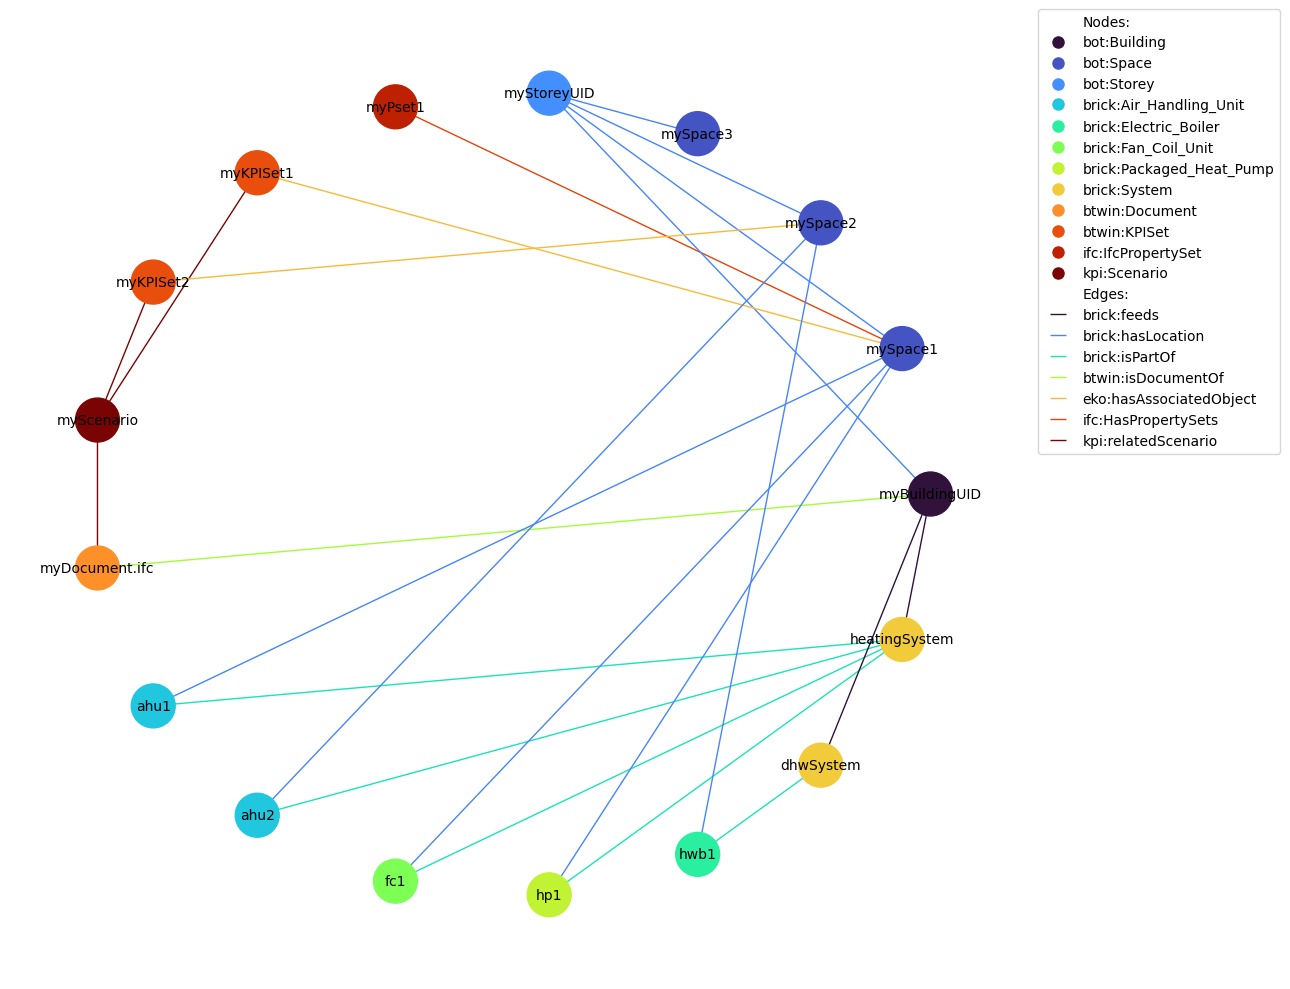

(<Figure size 1300x1000 with 1 Axes>, <Axes: >)

In [ ]:
# Render the graph as a static Matplotlib figure.
# Nodes are coloured by ontology type; adjust layout and nodeColorMap to taste.
GraphPlot.NetworkXByMatplotlib(
    nxGraph=nxGraph,
    showNodeLabels = True,
    showEdgeLabels = False,
    nodeColorMap = "turbo",
    nodeSize = 1000,
    nodeOpacity = 1.0,
    edgeColorMap = "turbo",
    edgeWidth = 1.0,
    savePath = None,
    figsize = (13, 10),
    showLegend = True,
    layout = "circular",
    layoutSeed = 10,
    dpi = 100,
)

In [ ]:
# Render the graph as an interactive Plotly figure.
# legendOutside=True moves the type legend beside the canvas to avoid overlap.
GraphPlot.NetworkXByPlotly(
        nxGraph=nxGraph,
        showNodeLabels = True,
        showEdgeLabels = False,
        nodeColorMap = "Turbo",     
        nodeSize = 12,               
        nodeOpacity = 1.0,
        edgeColorMap = "Turbo",
        edgeWidth = 1.0,
        savePath = None,     
        figsize = (1000, 500),  
        showLegend = True,
        layout = "circular",
        layoutSeed  = 42,
        legendOutside = True,  
    )